# Student Placement Prediction using Logistic Regression

This notebook builds a Machine Learning model to predict whether a student will be placed or not based on two features:

- CGPA
- IQ score

The project demonstrates a simple classification pipeline including data preprocessing, visualization, model training, and evaluation.

In [24]:
# Importing required libraries for data manipulation, visualization, and machine learning

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading the Dataset

The dataset contains information about students including their CGPA, IQ score, and whether they were placed or not.

In [48]:
# Loading the dataset that contains student CGPA, IQ scores, and placement status

df = pd.read_csv("placement.csv")

# Display first few rows of the dataset
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


## Data Understanding

Before building the model, we inspect the dataset structure, data types, and check for missing values.

In [49]:
# Checking the shape of the dataset (rows and columns)

df.shape

# Checking basic information about dataset
df.info()

# Checking for missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


Unnamed: 0    0
cgpa          0
iq            0
placement     0
dtype: int64

In [28]:
#steps
# Preprocess + EDA + Feature Selection
# Extract input and output cols
# scale the values -> so that values comes in same range
# train test split
# evaluate the model/ model selection
# deploy the model

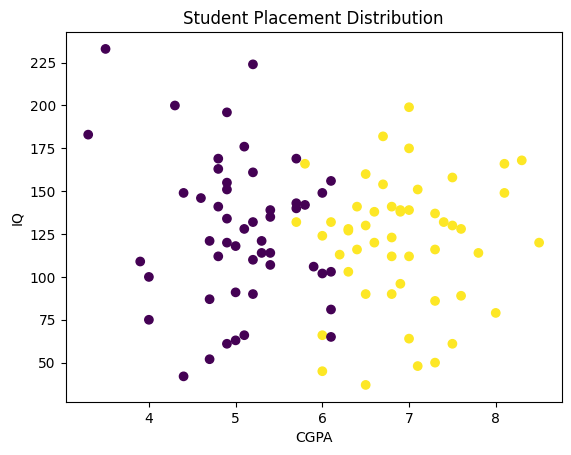

In [50]:
# Visualizing the relationship between CGPA, IQ and Placement

plt.scatter(df['cgpa'], df['iq'], c=df['placement'])
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.title("Student Placement Distribution")
plt.show()

## Feature Selection

The model will use:
- CGPA
- IQ

to predict the target variable:
- Placement

In [51]:
# Selecting input features (X) and target variable (y)

X = df[['cgpa', 'iq']]
y = df['placement']

## Train-Test Split

The dataset is divided into:
- Training set (used to train the model)
- Test set (used to evaluate the model)

In [52]:
# Splitting the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

## Feature Scaling

Feature scaling ensures that both CGPA and IQ contribute equally to the model.
StandardScaler standardizes the features by removing the mean and scaling to unit variance.

In [53]:
# Scaling the features so that CGPA and IQ are on the same scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training

We train a Logistic Regression classifier to predict whether a student will be placed or not.

In [54]:
# Training the Logistic Regression model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Model Prediction

The trained model is used to predict placement outcomes for the test data.

In [55]:
# Making predictions on the test dataset

y_pred = model.predict(X_test)

## Model Evaluation

The model performance is evaluated using accuracy score, which measures how many predictions were correct.

In [56]:
# Evaluating the performance of the model

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8


## Decision Boundary Visualization

This plot shows how the Logistic Regression model separates the two classes (placed vs not placed).

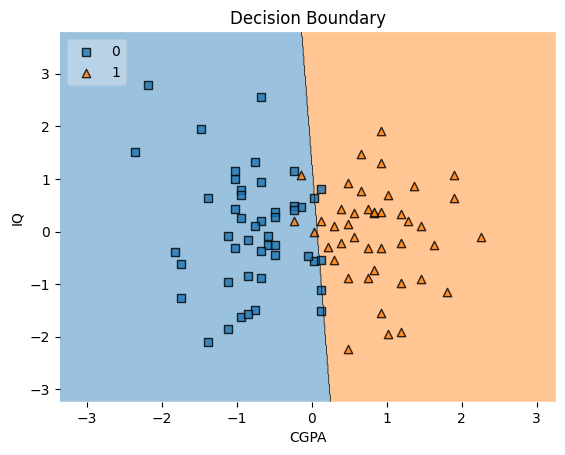

In [57]:
# Visualizing the decision boundary of the trained Logistic Regression model

from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_train, y_train.values, clf=model, legend=2)
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.title("Decision Boundary")
plt.show()

## Saving the Model

The trained model is saved using Pickle so it can be reused for predictions without retraining.

In [58]:
# Saving the trained model so it can be used later for deployment

import pickle

pickle.dump(model, open("placement_model.pkl", "wb"))

## Conclusion

In this notebook we:

- Explored the dataset
- Visualized the relationship between CGPA and IQ
- Trained a Logistic Regression model
- Evaluated the model using accuracy
- Visualized the decision boundary
- Saved the trained model for future use

This project demonstrates a basic Machine Learning classification workflow.